# CS 6470 A3 — Classification bake-off

**80 points** · Modules 6–7 (due Module 7) · plan for about 5–7 focused hours

**Before you submit, rename this file to `CS6470_A3_LastName_FirstName.ipynb`.**
Open it in [Google Colab](https://colab.research.google.com/) (File → Upload notebook) or local Jupyter (Python 3.10+).

## How this notebook works

- It has **5 numbered tasks**, top to bottom. Cells marked **`# YOUR CODE`** and Markdown cells marked **YOUR ANSWER** are the graded work. Cells marked *Runs as-is* are provided — run them and read them.
- Every coding task ends with a **Checkpoint** describing what you should see, so you always know whether you are on track. Small differences (±0.01–0.02 on scores) are normal.
- **Hints name the tool** (class, argument, or doc link), not a line to paste. Newer to Python? Follow the Hints. Comfortable? Try each task from the description first. Experienced? There is an ungraded stretch at the end of the assignment page.
- A `# YOUR CODE` cell raises `NotImplementedError` until you replace that line — that is the notebook telling you where to work, not a bug.
- Before submitting: **Runtime → Restart and run all.** Every cell must run with no errors and no `NotImplementedError` left.


## Setup and data *(runs as-is)*

**Dataset: German Credit** (OpenML `credit-g`) — 1,000 loan applicants, 20 features (7 numeric, 13 categorical), target `class`: `good` (70%) vs `bad` (30%) credit risk. Small enough that every grid finishes in seconds; imbalanced enough that accuracy alone misleads — a model that answers `good` every time is already "70% accurate".

The split and preprocessing follow the A1 pattern and are provided.


In [1]:
# Runs as-is — load, split, preprocessing.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             f1_score, recall_score)

data = fetch_openml("credit-g", version=1, as_frame=True, parser="auto")
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
num_cols = X_train.select_dtypes(include="number").columns.tolist()
cat_cols = X_train.select_dtypes(exclude="number").columns.tolist()
pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols),
])
print("train:", X_train.shape, "test:", X_test.shape)
print("class balance:", y.value_counts(normalize=True).round(2).to_dict())


train: (800, 20) test: (200, 20)
class balance: {'good': 0.7, 'bad': 0.3}


## Task 1 of 5 — The bake-off helper

Three algorithm families, one identical protocol. The cross-validation happens **inside the training split** (`cv=3`) — the test set is touched exactly once per model, at the end. That is what makes the tuning honest.

Complete `bake` below, then run it three times:

- `LogisticRegression(max_iter=1000)` with grid `{"clf__C": [0.5, 1.0]}`
- `DecisionTreeClassifier(random_state=42)` with grid `{"clf__max_depth": [3, 5]}`
- `GaussianNB()` with grid `{}` (nothing to tune)

**Hints.** Tools only:
- [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) around `Pipeline([("pre", pre), ("clf", clf)])`, `cv=3`, `scoring="f1_macro"`.
- Fit on the **training** split. Print `best_params_` and `best_score_`; return the fitted search without evaluating the test set. After all three searches finish, record the family with the highest `best_score_`, then print a final `classification_report` on the test split for each model.
- The `clf__` prefix on grid keys routes each entry to the Pipeline step named `clf`. Keep the three returned objects — Task 2 needs them.

**Checkpoint.** Show the requested results with labels and interpret your actual numbers. Exact parameters and scores may vary; full credit does not depend on matching a sample score.

Select the recommended family using training CV macro-F1 before comparing final test reports. Record each search's `best_score_`. Use test results to describe limitations, not to retune or switch winners. The cost discussion may motivate a different predeclared validation criterion in a future study; it does not make the test set reusable.


In [2]:
# YOUR CODE — Task 1. Complete the numbered blanks inside bake().

from re import search


def bake(name, clf, grid):
    """GridSearchCV(cv=3, scoring="f1_macro") over Pipeline(pre -> clf) on the training split only.
    Print the best params and training CV score. Return the fitted search without using the test set."""
    # 1. Build GridSearchCV around Pipeline(pre -> clf) with the given grid

    the = GridSearchCV(
    Pipeline([
        ("pre", pre),
        ("clf", clf)
    ]),
    grid,
    cv=3,
    scoring="f1_macro"
)
   
    # 2. Fit on the training split only
    the.fit(X_train, y_train)

    # 3. Print best_params_ + best_score_; return the search. Do not use the test set here.
    print(f"{name} best params: {the.best_params_}")
    print(f"{name} best CV score: {the.best_score_}")
    return the

logreg = bake("logistic", LogisticRegression(max_iter=1000), {"clf__C": [0.5, 1.0]})
tree = bake("tree", DecisionTreeClassifier(random_state=42), {"clf__max_depth": [3, 5]})
nb = bake("naive bayes", GaussianNB(), {})

# 4. Compare best_score_ across all three searches and record the selected family.

best_searches = {"logistic": logreg, "tree": tree, "naive bayes": nb}
best_family = max(best_searches, key=lambda k: best_searches[k].best_score_)
print(f"Selected family: {best_family}")

# 5. Only after recording that choice, print final test classification reports
#    for logreg, tree, and nb. Do not switch or retune based on test results.
print("Final test classification reports:")
for name, search in best_searches.items():
    print(f"{name} test report:")
    print(classification_report(y_test, search.predict(X_test)))


logistic best params: {'clf__C': 0.5}
logistic best CV score: 0.6865150310137992
tree best params: {'clf__max_depth': 3}
tree best CV score: 0.6194441861644242
naive bayes best params: {}
naive bayes best CV score: 0.5653473458890227
Selected family: logistic
Final test classification reports:
logistic test report:
              precision    recall  f1-score   support

         bad       0.53      0.47      0.50        60
        good       0.78      0.82      0.80       140

    accuracy                           0.71       200
   macro avg       0.66      0.64      0.65       200
weighted avg       0.71      0.71      0.71       200

tree test report:
              precision    recall  f1-score   support

         bad       0.50      0.07      0.12        60
        good       0.71      0.97      0.82       140

    accuracy                           0.70       200
   macro avg       0.60      0.52      0.47       200
weighted avg       0.65      0.70      0.61       200

naive bayes

## Task 2 of 5 — Confusion matrix + the right metric

In code:

1. Plot the confusion matrix for your model with the highest training CV macro-F1 (`best_score_`) on the test split.
2. For **each** of the three models, print recall on the `bad` class — the share of genuinely risky applicants the model actually catches.

**Hints.** Tools only:
- [`ConfusionMatrixDisplay.from_estimator`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) on the model selected by training CV, then `plt.show()`.
- [`recall_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html) with `pos_label="bad"` for each of the three fitted searches.

**Checkpoint.** Show the requested results with labels and interpret your actual numbers. Exact parameters and scores may vary; full credit does not depend on matching a sample score.


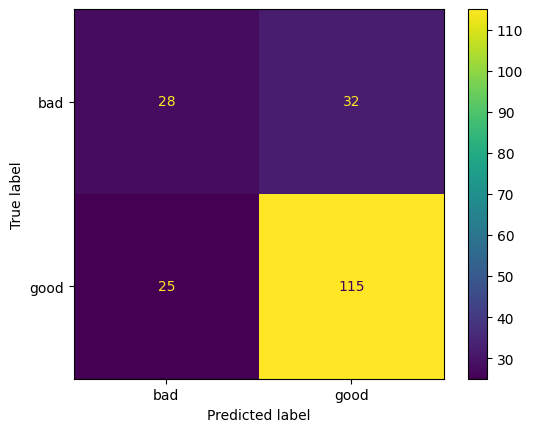

Logreg recall on the 'bad' class: 0.4666666666666667
Tree recall on the 'bad' class: 0.06666666666666667
NB recall on the 'bad' class: 0.6833333333333333


In [3]:
# YOUR CODE — Task 2. Write one small block under each comment.

# 1. Confusion matrix for the model selected by training CV on the test split, then plt.show()

ConfusionMatrixDisplay.from_estimator(logreg, X_test, y_test)
plt.show()

# 2. For each of logreg, tree, nb: print recall on the "bad" class

print("Logreg recall on the 'bad' class:", recall_score(y_test, logreg.predict(X_test), pos_label="bad"))
print("Tree recall on the 'bad' class:", recall_score(y_test, tree.predict(X_test), pos_label="bad"))
print("NB recall on the 'bad' class:", recall_score(y_test, nb.predict(X_test), pos_label="bad"))   


### Task 2 (written) — YOUR ANSWER

**Q1.** A model that answers `good` for everyone scores 70% accuracy here. Why does that make accuracy nearly useless for this dataset?

**TODO:** Because we are look for the bad applicants. The dataset is 70% good, so the model can get 70% accuracy by predicting everyone as good, even though it completely misses all of the bad applicants.

**Q2.** Point at the confusion-matrix cell that holds the *expensive* mistake for a lender, and say what happens in the real world when a case lands in it.

**TODO:** The model saying someone is good when they are actually bad is the most expensive mistake for the lender because they may give a loan to a risky applicant and lose money if they default. This is the false negative, which is the cell with 32 on my matrix. The model saying someone is bad when they are actually good is not as costly because the lender avoids taking the risk, although they may lose a good customer.



## Task 3 of 5 — Make one model inspectable

Refit a deliberately shallow tree and read it — inspectability means a human can follow the whole decision.

In code:

1. Fit `Pipeline(pre → DecisionTreeClassifier(max_depth=3, random_state=42))` on the training split.
2. Plot it with **real feature names** and readable size.

**Hints.** Tools only:
- Fit `Pipeline(pre → DecisionTreeClassifier(max_depth=3, random_state=42))` on train.
- Feature names: the `pre` step's `get_feature_names_out()`.
- Plot: [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) on the `clf` step — pass `feature_names`, `class_names=["bad", "good"]`, `filled=True`. Use a wide figure so the labels are readable.

**Checkpoint.** Show the requested results with labels and interpret your actual numbers. Exact parameters and scores may vary; full credit does not depend on matching a sample score.


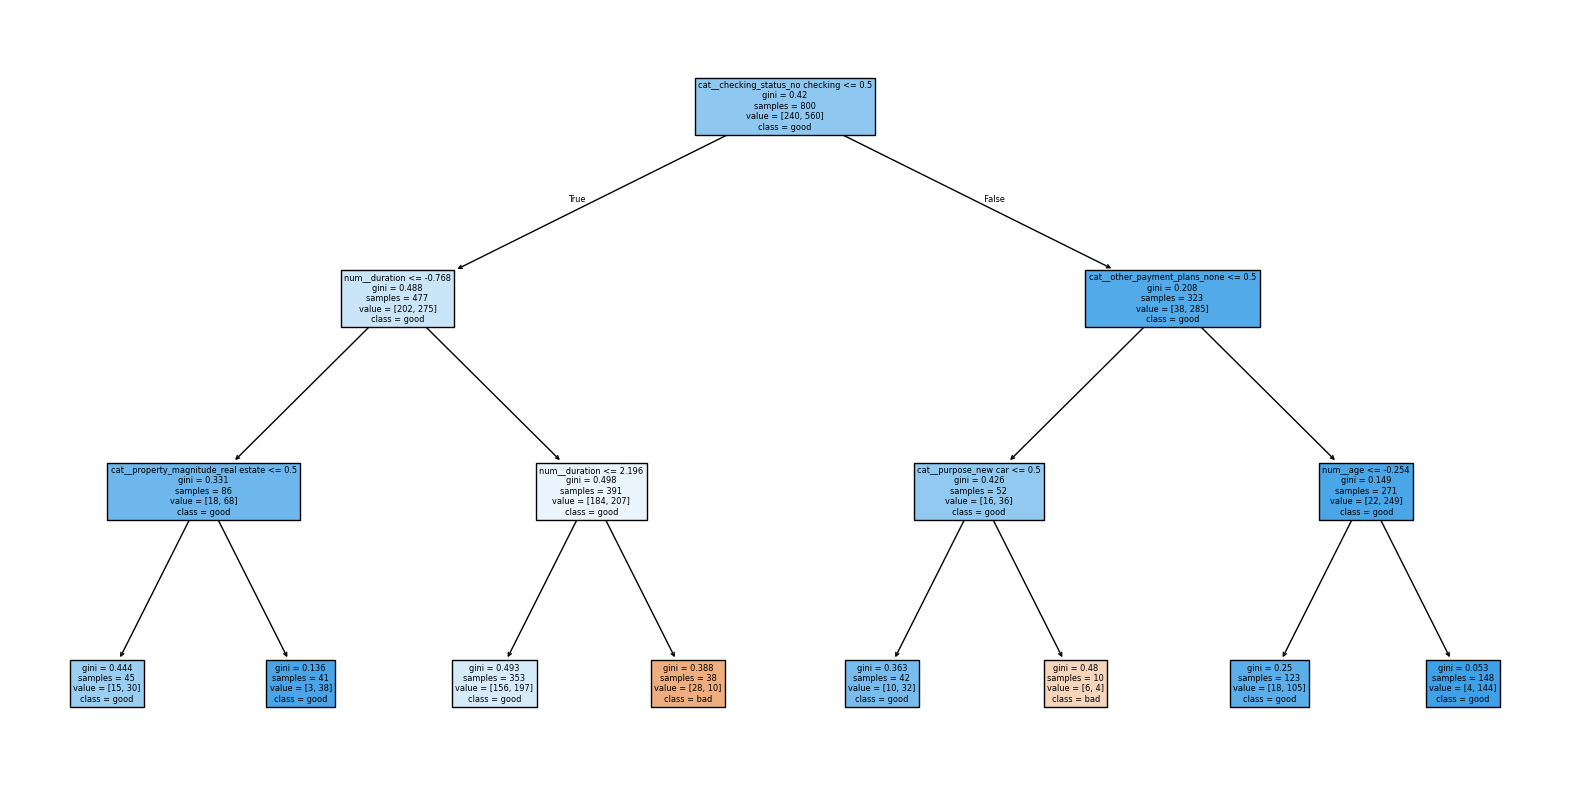

In [4]:
# YOUR CODE — Task 3. Write one small block under each comment.

# 1. Fit Pipeline(pre -> DecisionTreeClassifier(max_depth=3, random_state=42)) on train

tree3 = Pipeline(steps=[('pre', pre), ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))])
tree3.fit(X_train, y_train)

# 2. Get real feature names from the pre step

feature_names = tree3.named_steps['pre'].get_feature_names_out()

# 3. plot_tree with those names, then plt.show()

plt.figure(figsize=(20, 10))

plot_tree(tree3.named_steps['clf'], 
          feature_names=feature_names,
          class_names=["bad", "good"],
          filled=True)
plt.show()


### Task 3 (written) — trace one path — YOUR ANSWER

**TODO (2–4 sentences):**

The model starts with an applicant who has no checking account. They have another payment plan, and the purpose of the loan is a new car. The model classifies the applicant as bad, and there are 10 samples in this leaf.


## Task 4 of 5 — The cost story — YOUR ANSWER

Use `bad` as the positive class throughout. For a lender: a **false negative** (predicted `good`, actually `bad`) means money lent to someone who defaults. A **false positive** (predicted `bad`, actually `good`) means a good customer turned away.

**Q1.** Which error is more expensive for this lender, and by roughly what intuition (not exact dollars — reasoning)?

**TODO:** False negative would be more expensive for this lender. These are applicants who are actually bad but are predicted as good, so they may default on the loan and the lender could lose money.

**Q2.** Given that cost story, which metric would you predeclare for a future validation study, and why? Keep this assignment’s selected family fixed by training CV macro-F1; do not switch models using test results.

**TODO:** I would predeclare recall for the bad class because the lender wants to catch as many bad applicants as possible and avoid false negatives.


## Task 5 of 5 — Memo (≤1 page) — YOUR ANSWER

For a non-technical stakeholder who approves the rollout. Replace each **TODO**.

### My recommendation

**TODO:** I recommend logistic regression because it was the best overall. It had the highest score during our training, with a CV macro-F1 of about 69%. However, it only caught about 47% of the bad applicants on the final test, so I would want more validation before deploying it because missing bad applicants could cost the lender money.

### The trade I am accepting

**TODO:** The trade I am accepting is that while logistic regression gives the lender a better chance of catching bad applicants than the decision tree, its decision process is harder to follow. The decision tree is easier for a person to follow and see how it is making its decisions. With logistic regression, it is harder to see how the system is making its decisions.

### What I would watch after launch

**TODO:** I would watch the bad-class recall monthly or when we get an alert after launch. If it falls below 40%, meaning the system is catching fewer bad applicants, I would want an alert and would trigger a review of the system.

### AI disclosure

**TODO:** I used ChatGPT as a tutor to help me understand how everything was working together and to troubleshoot my code. All the code was mine.


## Before you submit

- [ ] File renamed to `CS6470_A3_LastName_FirstName.ipynb`
- [ ] **Runtime → Restart and run all** — every cell ran, no errors, no `NotImplementedError` anywhere
- [ ] All 5 tasks done: every `# YOUR CODE` cell has your code, every **YOUR ANSWER** / **TODO** prompt has your words
- [ ] Memo written in the Markdown cells above (it stays inside this notebook — no separate PDF)
- [ ] AI-use disclosure filled in
- [ ] The tree plot renders inside the notebook (no attached image files)

Upload the `.ipynb` file to this assignment on Canvas (in Colab: File → Download → Download .ipynb).

Integrity: the notebook and memo must be yours. AI may help explain an error; it may not be the submitted analysis.
